# Probability Simulations: From Brute Force to Statistical Mastery

This project explores the intersection of theoretical probability, computational simulations, and risk analysis. It moves beyond simple averages to investigate the full distribution of random events.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

---
## 1. Dice Probability: The Power of Convolution

Calculating the sum of multiple dice can be done via **Brute Force**, but this method fails as the number of dice increases. Instead, we use **Discrete Convolution** to calculate exact probabilities with extreme efficiency.

### The Analytical Approach vs. Efficiency
While a nested loop (Brute Force) has an exponential time complexity $O(s^n)$, Convolution allows us to determine the distribution in near-linear time. This is especially powerful when dealing with **weighted (unfair) dice**.

In [15]:
def dice_probability(n_dice,s_sides,k_target):
    total=s_sides**n_dice
    favourable=0
    for i in product(range(1,1+s_sides),repeat=n_dice):
        if sum(i)==k_target:
            favourable+=1
    return favourable/total
print(f"Probability: {dice_probability(3, 6, 8):.4%}")

Probability: 9.7222%


In [31]:
def weighted_dice_probability(n_dice, face_probs, target_sum):
    if target_sum < n_dice or target_sum > n_dice * len(face_probs):
        return 0.0
    dist=np.array(face_probs)
    final_dist=dist
    
    for i in range(n_dice-1):
        final_dist=np.convolve(final_dist,dist)
    index = target_sum - n_dice
    return final_dist[index]
    
prob = weighted_dice_probability(3, [0.1, 0.1, 0.1, 0.1, 0.1, 0.5], 15)
print(f"Probability of sum 15 (3 weighted dice): {prob:.4%}")
    

Probability of sum 15 (3 weighted dice): 10.6000%


---

## 2.The Coupon Collector Problem

The **Coupon Collector Problem** is a classic paradox that highlights the difference between "intuition" and "statistical reality." It asks: *How many trials are needed to collect all $n$ unique items?*

### The Harmonic Progression
Each time you collect a new face, the probability of finding the next unique face decreases. This creates a series of waiting times:
1. Waiting for the 1st face: $P = 6/6$, $E = 1$ roll.
2. Waiting for the 2nd face: $P = 5/6$, $E = 1.2$ rolls.
3. ...
4. Waiting for the 6th face: $P = 1/6$, $E = 6$ rolls.

The sum of these expectations forms a **Harmonic Series**:
$$E[T] = n \cdot H_n = n \sum_{i=1}^{n} \frac{1}{i}$$

--- Coupon Collector (n=6) ---
Analytical Expected Value: ~14.70
Simulated Mean Rolls:      14.69
P(X > 25 rolls):           6.18%
P(X > 50 rolls):           0.0560%


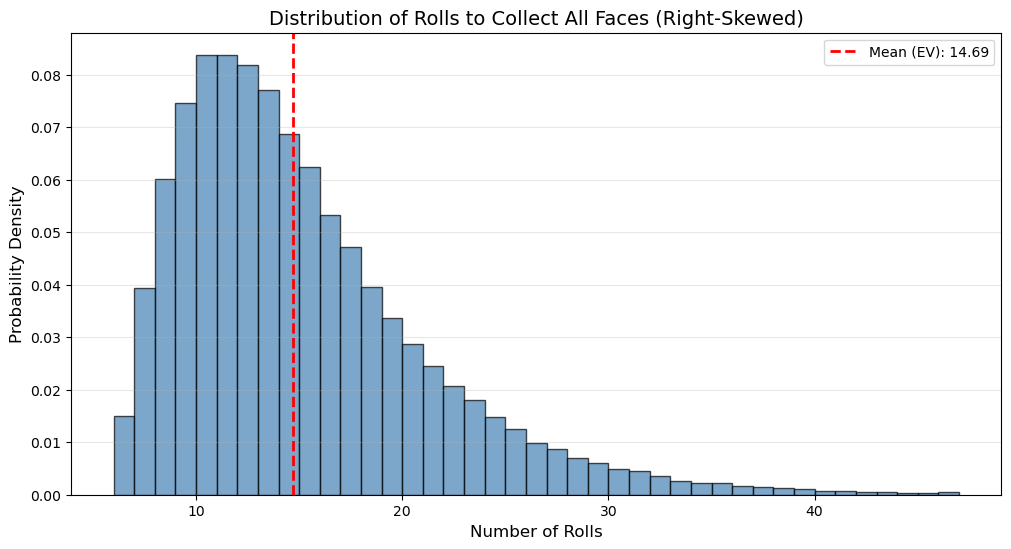

In [28]:
def coupon_collector_analysis(n_sides, n_simulations=100000):
    all_results = []
    for _ in range(n_simulations):
        seen = set()
        rolls = 0
        while len(seen) < n_sides:
            seen.add(np.random.randint(1, n_sides + 1))
            rolls += 1
        all_results.append(rolls)
    
    results = np.array(all_results)
    
    mean_val = np.mean(results)
    print(f"--- Coupon Collector (n={n_sides}) ---")
    print(f"Analytical Expected Value: ~14.70")
    print(f"Simulated Mean Rolls:      {mean_val:.2f}")
    print(f"P(X > 25 rolls):           {np.mean(results > 25):.2%}")
    print(f"P(X > 50 rolls):           {np.mean(results > 50):.4%}")
    
    return results

if __name__ == "__main__":
    n_sides = 6
    rolls_data = coupon_collector_analysis(n_sides)

    plt.figure(figsize=(12, 6))
    plt.hist(rolls_data, bins=range(n_sides, int(np.percentile(rolls_data, 99.9))), 
             color='steelblue', edgecolor='black', alpha=0.7, density=True)

    plt.axvline(np.mean(rolls_data), color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean (EV): {np.mean(rolls_data):.2f}')

    plt.title('Distribution of Rolls to Collect All Faces (Right-Skewed)', fontsize=14)
    plt.xlabel('Number of Rolls', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Relying solely on a **point estimate** (the Mean) is insufficient when dealing with non-symmetrical processes. The simulation reveals the true nature of the risk involved.

### 2.1 Distribution Asymmetry (Positive Skewness)
The simulation confirms that the required number of rolls is not Normally distributed. Instead, it exhibits a significant **positive skew**.

* **Mode vs. Mean:** The most frequent outcome (Mode) is lower than the Mean. The Mean ($\approx 14.7$) is pulled upward by infrequent, extreme values in the right tail.
* **Asymptotic Behavior:** This distribution is a sum of independent geometric random variables. As $n$ increases, the distribution asymptotically approaches a **Gumbel distribution**, characterized by its heavy right tail.

### 2.2 Quantifying Tail Risk
In risk management, the average outcome is often secondary to **Tail Risk**—the probability of extreme deviations from the mean.

* **Empirical Expectation:** $E[X] \approx 14.7$ rolls.
* **Tail Probability:** As shown in the simulation results, $P(X > 25) \approx 6.18\%$.

While a 6% probability might seem low, these **Tail Events** represent the risk of "statistical bad luck" that can deviate more than 3x from the expected value. Calculating $P(X > k)$ allows us to quantify the volatility of the process and move from naive data analysis to rigorous risk modeling.

---

## 3.Dice Games

The **Expected Value** is the long-term average outcome of a random variable. In the context of a dice game, it represents the average amount a player can expect to win or lose per game.

### The Mathematical Formula
For a discrete random variable $X$ (the payout), the Expected Value $E[X]$ is calculated as:
$$E[X] = \sum_{i=1}^{n} P(x_i) \cdot x_i$$
Where:
* $P(x_i)$ is the probability of a specific sum occurring.
* $x_i$ is the payout associated with that sum.


In [30]:
def calculate_game_ev(n_dice, face_probs, payout_map):
    ev=0
    dist=np.array(face_probs)
    final_dist=dist    
    
    for i in range(n_dice-1):
        final_dist=np.convolve(final_dist,dist)

    for i, prob in enumerate(final_dist):
        current_sum = i + n_dice
        payout = payout_map.get(current_sum, payout_map.get('else', 0))
        ev += prob * payout       
    return ev

# Win $5 on sum 7 or 11, lose $1 otherwise
rules = {7: 5, 11: 5, 'else': -1}
fair_probs = [1/6] * 6
game_ev = calculate_game_ev(2, fair_probs, rules)
print(f"\n--- Game Theory Analysis ---")
print(f"Expected Value of the Game: ${game_ev:.2f}")


--- Game Theory Analysis ---
Expected Value of the Game: $0.33
